# R02 - Routing

## Objetivo
Comparar `ShortestHopCountRouting`/`LeastLossRouting`/
`HighestFidelityRouting` com dados reais da campanha final
`F02_routing` (2 topologias: `diamond_heterogeneous`, `small_mesh`; 20
seeds cada). Ver `docs/routing_result_explanation.md` para a explicação
quantitativa completa do efeito no diamante, e
`docs/threats_to_validity.md` para por que esse efeito não generaliza a
toda topologia. Não roda simulação - carrega apenas dados persistidos.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from ibqn.experiments.aggregation import aggregate_records
from ibqn.experiments.export import save_figure, save_table

# Executed with cwd=notebooks/ regardless of this file's own subdirectory
# (tests/notebooks/test_notebooks.py's NotebookClient.execute(cwd=...)) -
# matches notebooks/article/A0*.ipynb's own convention, not a path
# relative to notebooks/article/final/ itself.
RESULTS_DIR = Path("../results")

# A dedicated subdirectory, not results/figures/final/ directly: that
# directory's *.pdf/*.png are the curated, audited figure set
# (scripts/generate_final_figures.py + sources.json, checked by
# scripts/audit_final_results.py) - a notebook's own reproducibility
# export must not silently add uncatalogued files there.
FIGURES_OUT = RESULTS_DIR / "figures" / "final" / "from_notebooks"
TABLES_OUT = RESULTS_DIR / "tables" / "final"


## Carregar dados e verificar consistência (2 blocos no manifesto)

In [2]:
CAMPAIGN = "F02_routing"
trials_df = pd.read_csv(RESULTS_DIR / "raw" / CAMPAIGN / "trials.csv")
manifest = json.load(open(RESULTS_DIR / "manifests" / f"{CAMPAIGN}.json", encoding="utf-8"))

assert len(trials_df) == manifest["completed_trials"]
assert len(manifest["blocks"]) == 2, "F02 runs two topologies, one block each"
for block in manifest["blocks"]:
    scenario_rows = trials_df[trials_df["scenario"] == block["scenario"]]
    assert len(scenario_rows) == block["completed_trials"], f"row count mismatch for {block['scenario']}"
print("blocks:", [(b["scenario"], b["completed_trials"]) for b in manifest["blocks"]])
trials_df.head(3)

blocks: [('diamond_heterogeneous', 60), ('small_mesh', 60)]


,campaign,trial_id,scenario,parameter_hash,seed,intent_id,routing_strategy,purification_policy,reconciliation_enabled,route,...,ep_success,es_attempts,es_success,violations,error_type,error_message,project_git_commit,sequence_git_commit,python_version,timestamp
0,F02_routing,F02_routing:diamond_heterogeneous:80436b1f968c...,diamond_heterogeneous,80436b1f968c95fe,0,intent-diamond-demo,shortest_hop_count,automatic,False,r1 -> bad -> r3,...,0,0,0,delivered_pairs >= 10.0 (observed=4.0) -> FAIL,NaN,NaN,f4343c314e5de5e01ee6970aaa14b5974c1b49ea,1f2680a5b9065e708a7497adc53a95b108029b98,3.13.14,2026-07-13T16:15:58.560578+00:00
1,F02_routing,F02_routing:diamond_heterogeneous:80436b1f968c...,diamond_heterogeneous,80436b1f968c95fe,1,intent-diamond-demo,shortest_hop_count,automatic,False,r1 -> bad -> r3,...,0,0,0,delivered_pairs >= 10.0 (observed=8.0) -> FAIL,NaN,NaN,f4343c314e5de5e01ee6970aaa14b5974c1b49ea,1f2680a5b9065e708a7497adc53a95b108029b98,3.13.14,2026-07-13T16:16:00.563015+00:00
2,F02_routing,F02_routing:diamond_heterogeneous:80436b1f968c...,diamond_heterogeneous,80436b1f968c95fe,2,intent-diamond-demo,shortest_hop_count,automatic,False,r1 -> bad -> r3,...,0,0,0,delivered_pairs >= 10.0 (observed=7.0) -> FAIL,NaN,NaN,f4343c314e5de5e01ee6970aaa14b5974c1b49ea,1f2680a5b9065e708a7497adc53a95b108029b98,3.13.14,2026-07-13T16:16:02.551950+00:00


## Agregação por topologia x estratégia

In [3]:
summary = aggregate_records(trials_df, group_by=["scenario", "routing_strategy"], metrics=["delivered_pairs", "average_fidelity"])
save_table(summary, "R02_summary", directory=TABLES_OUT)
summary[["scenario", "routing_strategy", "metric", "n_valid", "mean", "ci95_low", "ci95_high", "satisfaction_rate"]]

,scenario,routing_strategy,metric,n_valid,mean,ci95_low,ci95_high,satisfaction_rate
0,diamond_heterogeneous,highest_fidelity,delivered_pairs,20,7.850000,6.439608,9.260392,0.25
1,diamond_heterogeneous,highest_fidelity,average_fidelity,20,0.769500,0.769500,0.769500,0.25
2,diamond_heterogeneous,least_loss,delivered_pairs,20,446.100000,441.215202,450.984798,1.00
3,diamond_heterogeneous,least_loss,average_fidelity,20,0.657922,0.657922,0.657922,1.00
4,diamond_heterogeneous,shortest_hop_count,delivered_pairs,20,7.850000,6.439608,9.260392,0.25
5,diamond_heterogeneous,shortest_hop_count,average_fidelity,20,0.769500,0.769500,0.769500,0.25
6,small_mesh,highest_fidelity,delivered_pairs,20,697.200000,694.041792,700.358208,1.00
7,small_mesh,highest_fidelity,average_fidelity,20,0.447555,0.447555,0.447555,1.00
8,small_mesh,least_loss,delivered_pairs,20,696.000000,692.293017,699.706983,1.00
9,small_mesh,least_loss,average_fidelity,20,0.447555,0.447555,0.447555,1.00


## Comparações estatísticas pareadas

In [4]:
stats_df = pd.read_csv(RESULTS_DIR / "processed" / CAMPAIGN / "statistical_comparisons.csv")
significant = stats_df[stats_df["p_value_holm_adjusted"] < 0.05]
print(f"{len(significant)}/{len(stats_df)} comparisons significant after Holm correction")
significant[["scenario", "value_col", "group_a", "group_b", "n", "mean_a", "mean_b", "test_used", "p_value_holm_adjusted", "effect_size"]]

8/24 comparisons significant after Holm correction


,scenario,value_col,group_a,group_b,n,mean_a,mean_b,test_used,p_value_holm_adjusted,effect_size
0,diamond_heterogeneous,delivered_pairs,highest_fidelity,least_loss,20,7.850000,446.100000,paired_t,1.937119e-31,39.011871
2,diamond_heterogeneous,delivered_pairs,least_loss,shortest_hop_count,20,446.100000,7.850000,paired_t,1.937119e-31,-39.011871
3,diamond_heterogeneous,average_fidelity,highest_fidelity,least_loss,20,0.769500,0.657922,wilcoxon,6.886863e-05,-1.000000
5,diamond_heterogeneous,average_fidelity,least_loss,shortest_hop_count,20,0.657922,0.769500,wilcoxon,6.886863e-05,1.000000
6,diamond_heterogeneous,satisfied_num,highest_fidelity,least_loss,20,0.250000,1.000000,wilcoxon,3.225335e-04,1.000000
8,diamond_heterogeneous,satisfied_num,least_loss,shortest_hop_count,20,1.000000,0.250000,wilcoxon,3.225335e-04,-1.000000
9,diamond_heterogeneous,first_pair_latency_s,highest_fidelity,least_loss,20,0.018942,0.001338,paired_t,1.082760e-06,-1.697793
11,diamond_heterogeneous,first_pair_latency_s,least_loss,shortest_hop_count,20,0.001338,0.018942,paired_t,1.082760e-06,1.697793


## Figura (diamante, escala log - ver docs/routing_result_explanation.md)

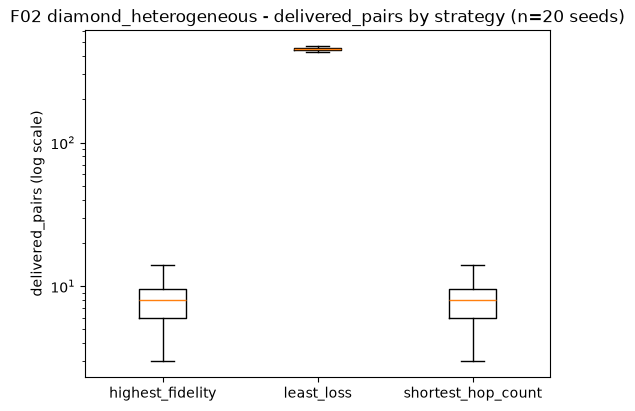

In [5]:
diamond = trials_df[trials_df["scenario"] == "diamond_heterogeneous"]
strategies = sorted(diamond["routing_strategy"].unique())
fig, ax = plt.subplots(figsize=(6, 4.5))
groups = [diamond[diamond["routing_strategy"] == s]["delivered_pairs"].to_numpy() for s in strategies]
ax.boxplot(groups, tick_labels=strategies, showfliers=False)
ax.set_yscale("log")
ax.set_ylabel("delivered_pairs (log scale)")
ax.set_title(f"F02 diamond_heterogeneous - delivered_pairs by strategy (n={diamond['seed'].nunique()} seeds)")
save_figure(fig, "R02_diamond_delivered_pairs", directory=FIGURES_OUT)
plt.show()

## Conclusão

O ganho de `least_loss` (~56x) é causado pela perda óptica acumulada da
rota, não pela fidelidade nem pelo número de saltos isoladamente - ver
a ficha por rota completa em `docs/routing_result_explanation.md`. Na
malha pequena (mesma campanha), as 3 estratégias são equivalentes -
o efeito é específico da topologia diamante.

## Limitações

O ganho de `least_loss` no diamante (~56x) é específico desta topologia (ver `docs/routing_result_explanation.md`) - a malha pequena, na mesma campanha, não mostra o mesmo efeito.